# MovieRecommandSystem

## Import packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from colour import Color
from sklearn.feature_extraction.text import TfidfVectorizer
import json
import numpy as np
import math
import warnings
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

## Data Screening
- Finding 1: inconsistent data type
    - Solution: define a reusable function to deal with **str** of list of dict, and grab specific values in the dict, and apply the function to standardlize other columns
- Finding 2: missing values
    - Solution: data imputation

In [2]:
movie = pd.read_csv('tmdb_5000_movies.csv')
movie.sample(5)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
1732,28000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 35, ""name...",NaN,15198,"[{""id"": 6075, ""name"": ""sport""}, {""id"": 6483, ""...",en,"Mystery, Alaska","In Mystery, Alaska, life revolves around the l...",4.436792,"[{""name"": ""Hollywood Pictures"", ""id"": 915}]","[{""iso_3166_1"": ""CA"", ""name"": ""Canada""}, {""iso...",1999-10-01,8888143,119.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A Small Town on the Outskirts of Greatness.,"Mystery, Alaska",6.0,69
80,170000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://www.snowwhiteandthehuntsman.com/,58595,"[{""id"": 2011, ""name"": ""queen""}, {""id"": 2343, ""...",en,Snow White and the Huntsman,"After the Evil Queen marries the King, she per...",77.178973,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-05-30,396600000,127.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Fairytale is Over,Snow White and the Huntsman,5.8,3118
1568,30000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 53, ""nam...",http://loopermovie.com/,59967,"[{""id"": 236, ""name"": ""suicide""}, {""id"": 782, ""...",en,Looper,"In the futuristic action thriller Looper, time...",46.377628,"[{""name"": ""Endgame Entertainment"", ""id"": 1205}...","[{""iso_3166_1"": ""CN"", ""name"": ""China""}, {""iso_...",2012-09-26,47042000,118.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Hunted By Your Future, Haunted By Your Past",Looper,6.6,4697
4239,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10751, ""n...",NaN,39541,[],en,Stolen Summer,"Pete, an eight-year-old Catholic boy growing u...",0.870660,[],[],2002-03-22,0,91.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,You saw the back-stabbing. Now see the final cut.,Stolen Summer,6.4,9
3645,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10769, ""n...",http://gandhimyfather.erosentertainment.com/,38428,"[{""id"": 5565, ""name"": ""biography""}, {""id"": 792...",hi,"Gandhi, My Father","With Gandhi My Father, producer Anil Kapoor an...",0.080704,[],"[{""iso_3166_1"": ""IN"", ""name"": ""India""}]",2007-08-03,0,136.0,"[{""iso_639_1"": ""hi"", ""name"": ""\u0939\u093f\u09...",Released,To the People...He was a Father. To his Son......,"Gandhi, My Father",6.0,2


In [3]:
movie.shape

(4803, 20)

In [4]:
movie.dtypes

budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

In [5]:
movie['genres'][1]

'[{"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 28, "name": "Action"}]'

## Data cleaning

### Reusable funtion 1: Standardize data type
- Remove str and list and extract the value of names

In [6]:
"""
- Date: 2/28/2026
- Author: Shuang Liu
- Function: 
    Define a reusable function to deal with **str** of list of dict, and grab specific values in the dict, and apply the function to standardlize other columns
- Parameter: 
    data_name: name of a pandas data_frame
    column: the column name to change type(string)
    key: the keyword we are extracting(string)
- Output:
    new: the output clean column(pandas data_frame)
"""
def get_name(data_name, column, key):
    new = []
    for i in range(0, len(data_name)):      
        g = json.loads(data_name[column][i])
        names = []
        for j in g:
            names.append(j[key])
        new.append(names)
    return new



In [7]:
# replace the old column genres
movie['genres'] = get_name(movie, 'genres', 'name')

In [8]:
# replace the old column keywords
movie['keywords'] = get_name(movie, 'keywords', 'name')

In [9]:
movie.sample(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
2117,20000000,"[Thriller, Horror, Drama, Mystery]",http://www.uip.de/lo/goodies/posters/pl_boogey...,8968,"[nightmare, hallucination, childhood trauma, b...",en,Boogeyman,Every culture has one – the horrible monster f...,11.62423,"[{""name"": ""Ghost House Pictures"", ""id"": 768}, ...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2005-02-04,67192859,89.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,You thought it was just a story.,Boogeyman,4.6,191


In [10]:
# replace the old column spoken_languages
movie['spoken_languages'] = get_name(movie, 'spoken_languages', 'name')

### Clean missing values

In [11]:
# Remove rows with empty genres
movie = movie[movie['genres'].map(lambda x: len(x) > 0)]

In [12]:
movies_with_no_keywords = movie[movie['keywords'].map(lambda x: len(x) == 0)]
print(len(movies_with_no_keywords))

386


In [13]:
movies_with_no_spoken_languages = movie[movie['spoken_languages'].map(lambda x: len(x) == 0)]
print(len(movies_with_no_spoken_languages))

67


In [14]:
# Remove rows with empty spoken_languages
language_empty = movie[movie['spoken_languages'].map(lambda x: len(x) == 0)]
# print(language_empty['title'])

In [15]:
print(len(movie))

4775


### Find uninformative variables

In [16]:
# Drop redundant variables
variables_to_drop = ['homepage', 'original_title', 'tagline']
"""Syntax: df.drop(list, axis=1, inplace = True)"""
movie.drop(variables_to_drop, axis = 1, inplace = True)

In [17]:
"""Syntax: df['column'].value_counts()"""
movie['status'].value_counts()

status
Released           4767
Rumored               5
Post Production       3
Name: count, dtype: int64

In [18]:
# Only keep 'released' movie
movie = movie[movie['status'] == 'Released']

In [19]:
# Drop redundant status(repeated values)
movie.drop(['status'], axis = 1, inplace = True)

### Double check missing values

In [20]:
"""
Syntax: df.isna().sum()
check number of NA for all columns
"""
movie.isna().sum()

budget                  0
genres                  0
id                      0
keywords                0
original_language       0
overview                3
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 2
spoken_languages        0
title                   0
vote_average            0
vote_count              0
dtype: int64

In [21]:
print(movie[movie['overview'].isna()]['title'])

2656    Chiamatemi Francesco - Il Papa della gente
4140                   To Be Frank, Sinatra at 100
4431                                   Food Chains
Name: title, dtype: object


In [22]:
print(movie[movie['runtime'].isna()]['title'])

2656    Chiamatemi Francesco - Il Papa della gente
4140                   To Be Frank, Sinatra at 100
Name: title, dtype: object


In [23]:
"""
Syntax: df.loc[filter_condition, column_to_edit] = new_content
"""
movie.loc[movie['title'] == 'Chiamatemi Francesco - Il Papa della gente', 'overview'] = "The film covers Bergoglio's vocation, his life as a Jesuit educator, his time as Archbishop and Cardinal of Buenos Aires, and his eventual election to the Papacy."
movie.loc[movie['title'] == 'Chiamatemi Francesco - Il Papa della gente', 'runtime'] = 98
movie.loc[movie['title'] == 'To Be Frank, Sinatra at 100', 'overview'] = "The life of Frank Sinatra, as an actor and singer and the steps along the way that led him to become such an icon."
movie.loc[movie['title'] == 'To Be Frank, Sinatra at 100', 'runtime'] = 81
movie.loc[movie['title'] == 'Food Chains', 'overview'] = "Food is widely appreciated today, but little attention is given to the workers who produce it. In the U.S., powerful supermarkets keep wages low, forcing vulnerable farmworkers to endure ongoing exploitation."

In [24]:
movie[movie['title'] == "Food Chains"] 

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
4431,913000,[Documentary],292539,[],de,"Food is widely appreciated today, but little a...",0.795698,[],[],2014-04-26,0,83.0,[English],Food Chains,7.4,8


In [25]:
movie.isna().sum()

budget                  0
genres                  0
id                      0
keywords                0
original_language       0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
title                   0
vote_average            0
vote_count              0
dtype: int64

## Deal with second dataset

In [26]:
credit = pd.read_csv('tmdb_5000_credits.csv')
credit.sample(5)

,movie_id,title,cast,crew
4144,3766,The Lady from Shanghai,"[{""cast_id"": 4, ""character"": ""Elsa Bannister"",...","[{""credit_id"": ""52fe43a4c3a36847f80640e9"", ""de..."
2788,13435,Antwone Fisher,"[{""cast_id"": 1, ""character"": ""Antwone Quenton ...","[{""credit_id"": ""59037a43c3a3683be9001540"", ""de..."
1980,70868,I Don't Know How She Does It,"[{""cast_id"": 5, ""character"": ""Kate Reddy"", ""cr...","[{""credit_id"": ""52fe4816c3a368484e0e8a5b"", ""de..."
654,36648,Blade: Trinity,"[{""cast_id"": 3, ""character"": ""Blade"", ""credit_...","[{""credit_id"": ""52fe45fd9251416c910455ef"", ""de..."
3356,2074,Flirting with Disaster,"[{""cast_id"": 6, ""character"": ""Mel Coplin"", ""cr...","[{""credit_id"": ""52fe4332c3a36847f8041b2f"", ""de..."


In [27]:
print(credit.shape)

(4803, 4)


## Clean missing cast and crew

In [28]:
credit = credit[credit['cast'] != '[]']
credit = credit[credit['crew'] != '[]']

In [29]:
"""
Syntax: df.reset_index(drop = True)
"""
credit = credit.reset_index(drop = True)

In [30]:
# Clean cast
credit['cast'] = get_name(credit, 'cast', 'name')

In [31]:
credit.sample(5)

,movie_id,title,cast,crew
4184,1999,In the Bedroom,"[Tom Wilkinson, Sissy Spacek, Nick Stahl, Mari...","[{""credit_id"": ""52fe432ac3a36847f803f5e7"", ""de..."
1358,817,Austin Powers: The Spy Who Shagged Me,"[Mike Myers, Heather Graham, Michael York, Rob...","[{""credit_id"": ""52fe427bc3a36847f8022011"", ""de..."
4248,408,Snow White and the Seven Dwarfs,"[Adriana Caselotti, Lucille La Verne, Harry St...","[{""credit_id"": ""52fe4240c3a36847f800fa21"", ""de..."
1332,96721,Rush,"[Daniel Brühl, Chris Hemsworth, Olivia Wilde, ...","[{""credit_id"": ""52fe49bf9251416c750d20f1"", ""de..."
1231,64685,Extremely Loud & Incredibly Close,"[Thomas Horn, Tom Hanks, Sandra Bullock, Max v...","[{""credit_id"": ""52fe46e4c3a368484e0a9895"", ""de..."


### Feature engineering:
Create a new feature base on original variables

In [32]:
# Goal: extract the star in cast.
credit['star'] = credit['cast'].apply(lambda line: line[0])

In [33]:
#crew = json.loads(credit['crew'][0])
#crew1 = json.loads(credit['crew'])
# Filter with condition: job = Director
# Extract name of director
"""for c in crew:
    if c['job'] == 'Director':
        name = c['name']
        print(name)"""
director = []
for i in range(0, len(credit)):
    crew = json.loads(credit['crew'][i])
    for c in crew:
        if c['job'] == 'Director':
            name = c['name']
            director.append(name)
# create new column by generating new df
credit['director'] = pd.DataFrame(director)
# Drop original column crew
credit.drop(['crew'], axis=1, inplace = True)

In [34]:
credit.sample(3)

,movie_id,title,cast,star,director
961,1907,The Beach,"[Leonardo DiCaprio, Guillaume Canet, Tilda Swi...",Leonardo DiCaprio,Guillermo del Toro
3391,1956,Gerry,"[Casey Affleck, Matt Damon]",Casey Affleck,Vic Sarin
3141,250066,American Heist,"[Hayden Christensen, Adrien Brody, Jordana Bre...",Hayden Christensen,Jamie Thraves


### Merge dataset from multiple sources

In [35]:
# Rename column to make unique id consistent
"""
Syntax: df = df.rename(columns = {'old_name': 'new_name'})
"""
credit = credit.rename(columns = {'movie_id': 'id'})
credit.head(3)

,id,title,cast,star,director
0,19995,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",Sam Worthington,James Cameron
1,285,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Johnny Depp,Gore Verbinski
2,206647,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Daniel Craig,Sam Mendes


In [36]:
# Drop repeated columns
credit.drop(['title'], axis = 1, inplace = True)
credit.head(3)

,id,cast,star,director
0,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",Sam Worthington,James Cameron
1,285,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Johnny Depp,Gore Verbinski
2,206647,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Daniel Craig,Sam Mendes


In [37]:
credit.shape

(4753, 4)

In [38]:
movie.shape

(4767, 16)

### Method 1: LEFT join on movie

In [39]:
"""
Syntax: df_new = left_table.merge(right_table, on = 'unique_id', how = 'method')
"""
movie1 = movie.merge(credit, on = 'id', how = 'left')

movie1.sample(2)

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,star,director
1650,30000000,"[Action, Science Fiction]",10350,"[fight, pilot, outer space, based on video gam...",en,The Hollywood version of the popular video gam...,5.259585,"[{""name"": ""Carousel Picture Company, The"", ""id...","[{""iso_3166_1"": ""LU"", ""name"": ""Luxembourg""}, {...",1999-03-11,0,100.0,[English],Wing Commander,4.0,72,"[Freddie Prinze Jr., Saffron Burrows, Matthew ...",Freddie Prinze Jr.,Sam Raimi
3839,0,"[Horror, Thriller]",22007,[],en,This new Train tells the tale of an American w...,3.280081,"[{""name"": ""Nu Image Films"", ""id"": 925}, {""name...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2008-10-16,0,94.0,[English],Train,4.8,36,"[Thora Birch, Gideon Emery, Gloria Votsis, Der...",Thora Birch,Stiles White


In [40]:
# check movies without star
movie1[movie1['star'].isnull()].sample(3)

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,star,director
3660,0,[Drama],19615,[],en,A real estate developer goes to his 25th high ...,1.546169,[],[],2009-01-01,0,95.0,[English],Flying By,7.0,2,NaN,NaN,NaN
4117,7000000,"[Animation, Family, Foreign]",20653,[],en,This is the story of Romeo. A dude who was liv...,0.253595,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""IN"", ""name"": ""India""}, {""iso_...",2008-10-24,1100000,93.0,"[English, हिन्दी]",Roadside Romeo,6.7,3,NaN,NaN,NaN
4616,0,[Horror],325123,[],en,A beautiful diva is murdered on the set of hor...,0.055325,[],[],2015-03-10,0,96.0,[English],Teeth and Blood,3.0,1,NaN,NaN,NaN


- Finding: movies with missing values of cast and crew are all unpopular movies with few votes(<20)

### Method 2: INNER join

In [41]:
# Default setting of how = inner_join
movie2 = movie.merge(credit, on = 'id')
movie2
# update dataset
movie = movie2

## Demographic Filtering
### Functionality: 
- **Generalized** recommandation(for everyone)
- **Based on**: ratings(overall user ratings)
- **Solution**: self-define a *weighted rating(score)* matrix for every movie to recommend the best rated movies.

$$score = \frac{C_1}{C_1+C_0}\times R_1+\frac{C_0}{C_1+C_0}\times R_n$$

- $C_1$: Vote Count, number of votes of each movie
- $R_1$: vote average, average rating for each movie
- $C_0$: the lowest number of vote allowed to enter the system
- $R_n$: average rating for all the movies in the dataset

In [42]:
# C1
C1 = movie['vote_count']
# R1
R1 = movie['vote_average']
# C0: top 10%, better than 90%
C0 = movie['vote_count'].quantile(0.9)
# Rn
Rn = movie['vote_average'].mean()
# define a new metric:
score = C1/(C1+C0)*R1 + C0/(C1+C0)*Rn
movie['score'] = pd.DataFrame(score)
movie.sample(1)

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,star,director,score
1098,45000000,"[Drama, Romance]",6639,"[sex, marriage proposal, new love, colombia, l...",en,"In Colombia just after the Great War, an old m...",5.361699,"[{""name"": ""New Line Cinema"", ""id"": 12}, {""name...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-10-04,4607608,139.0,[English],Love in the Time of Cholera,6.4,81,"[Javier Bardem, Unax Ugalde, Benjamin Bratt, C...",Javier Bardem,Patrick Read Johnson,6.134712


### Reusable function 2: calculate generalize scores for any given movie dataset

In [43]:
"""
- Date: 4/1/2026
- Author: Shuang Liu
- Function: A reusable function that can calculate generalize scores for any given movie dataset
- Parameters: 
    df: input a pandas dataframe.
    count_name: name of the vote_count column
    avg_name: name of the vote_average column
    q: quantile for lowest count allowed to enter this system

- Output: 
    score: calculated score base on the IMDb formula

"""

def calculate_scores(df, count_name, avg_name, q):
    C1 = df[count_name]
    R1 = df[avg_name]
    C0 = df[count_name].quantile(q)
    Rn = df[avg_name].mean()
    score = round(C1/(C1+C0)*R1 + C0/(C1+C0)*Rn, 3)
    return pd.DataFrame(score)

In [44]:
# testing
movie['score'] = calculate_scores(movie, 'vote_count', 'vote_average', 0.9)
# get top 10 ratings
top10 = movie.sort_values(by = 'score', ascending = False).head(10)
#extract movie name and score
top = top10[['title','score']]
# update index 1-10
top.index = np.arange(1, 11)
top

,title,score
1,The Shawshank Redemption,8.057
2,Fight Club,7.938
3,The Dark Knight,7.919
4,Pulp Fiction,7.903
5,Inception,7.862
6,The Godfather,7.849
7,Interstellar,7.808
8,Forrest Gump,7.802
9,The Lord of the Rings: The Return of the King,7.726
10,The Empire Strikes Back,7.697


### Reusable function 3: get top n by category

In [45]:
"""
- Date: 4/1/2026
- Author: Shuang Liu
- Function: A reusable function that can get top n films by category from DF
- Parameters: 
    df: input a pandas dataframe.
    category(string): sort by this feature
    n: top n lines
    column: a list of column names to keep(list of strings)

- Output: 
    topn_col: dataframe containing top n lines

"""
def get_topn(df, category, n = int, column = list):
    topn_col = df.sort_values(by = category, ascending = False).head(n)
    tops = topn_col[column]
    tops.index = np.arange(1, n + 1)
    return tops
    
# testing function, get_top5 best rated movies

get_topn(movie, 'score', 5, ['title','score'])

,title,score
1,The Shawshank Redemption,8.057
2,Fight Club,7.938
3,The Dark Knight,7.919
4,Pulp Fiction,7.903
5,Inception,7.862


## Common characteristics of pop scored movies

In [46]:
# top n persent of movie
pct = int(input('% of top scored:'))
topn_info = get_topn(
    movie, 'score', 
    round(len(movie)*pct/100), 
    ['title','score', 'genres', 'star', 'director', 'keywords', 'release_date'])

% of top scored: 5


### 1.top scored movies-genres
### Reusable funtion 4: count word frequency in list of lists

In [47]:
"""
- Date: 4/8/2026
- Author: Shuang Liu
- Function: A reusable function that can get number of appearance of each word in list of lists
- Parameters: 
    df: input a pandas dataframe.
    variable: variables to count words from
    n: get top n largest amount

- Output: 
    D: a dict with words and counts
"""
def count_words(df, variable, n = 1):
    variables = {}
    for i in df[variable]:
        for j in i:
            if j in variables:
                variables[j] += 1
            else:
                variables[j] = 1
    D = dict(sorted(variables.items(), key = lambda x: x[1], reverse = True))
    
    D = dict(Counter(D).most_common(n))
    
    return D
top_genre = count_words(topn_info, 'genres', n = 15)
top_genre

{'Drama': 125,
 'Action': 73,
 'Adventure': 73,
 'Thriller': 61,
 'Science Fiction': 48,
 'Fantasy': 42,
 'Crime': 41,
 'Comedy': 40,
 'Family': 37,
 'Animation': 27,
 'Romance': 26,
 'Mystery': 22,
 'War': 13,
 'Horror': 10,
 'History': 8}

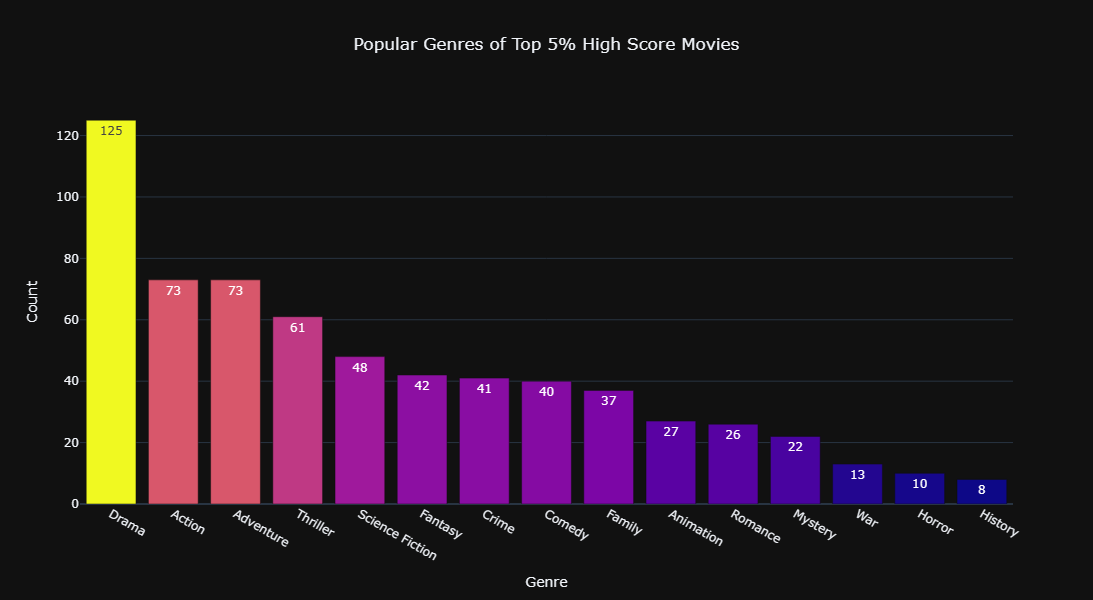

In [48]:
# Update: Interactive data visualization

genre_df = pd.DataFrame(list(top_genre.items()), columns=["genres", "count"])
fig = px.bar(
    data_frame=genre_df,
    x = 'genres',
    y = 'count',
    title = f'Popular Genres of Top {pct}% High Score Movies',
    color = 'count',
    color_continuous_scale = px.colors.sequential.Plasma,
    text = 'count'
)
fig.update_layout(
    width = 800,
    height = 600,
    template = "plotly_dark",
    title_x = 0.5,
    xaxis_title = 'Genre',
    yaxis_title = 'Count',
    coloraxis_showscale = False
)
fig.show()

### 2. Stars

In [49]:
top_star = topn_info['star'].value_counts().head(1).index[0]
print(f'Most Popular Star of Top {pct}% Movies:\n\t {top_star}')

Most Popular Star of Top 5% Movies:
	 Leonardo DiCaprio


### 3. Directors

In [50]:
top_director = topn_info['director'].value_counts().head(1).index[0]
print(f'Most Popular Director of Top {pct}% Movies:\n\t {top_director}')

Most Popular Director of Top 5% Movies:
	 Roland Emmerich


### 4. Keywords

In [51]:
top_keywords = count_words(topn_info, 'keywords', n = 15)

### Generate word cloud for popular movie themes

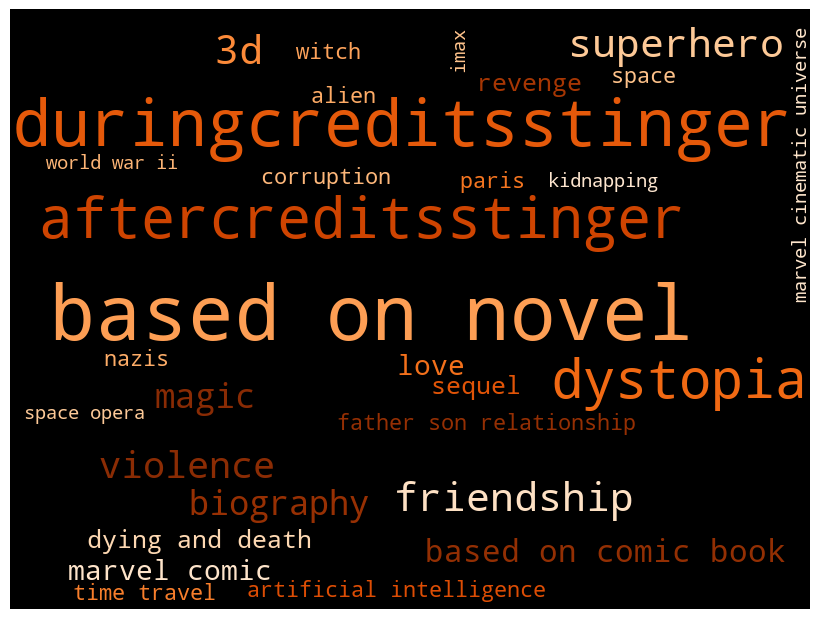

In [52]:

d = count_words(topn_info, 'keywords', n = 30)
word_cloud = WordCloud(
    width = 800,
    height = 600,
    background_color = "black",
    colormap = 'Oranges',
    relative_scaling = 1    
).generate_from_frequencies(d)
plt.figure(figsize=(12, 6))
plt.imshow(word_cloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

### Finding: 
- Based on novel has a relative higher value than other keywords. This might because a good novel could ensure a good plot.
- During credits stinger is the second one.
- Super hero has a higher value when the pct is low. When the pct higher, such as 15%, 3d and super hero will drop and violence and friendship will rise.

In [53]:
topn_info['release_decade'] = topn_info['release_date'].apply(lambda x: x[:3]+"0's")
topn_info.head(3)

,title,score,genres,star,director,keywords,release_date,release_decade
1,The Shawshank Redemption,8.057,"[Drama, Crime]",Tim Robbins,Brian Levant,"[prison, corruption, police brutality, prison ...",1994-09-23,1990's
2,Fight Club,7.938,[Drama],Edward Norton,Gary Shore,"[support group, dual identity, nihilism, rage ...",1999-10-15,1990's
3,The Dark Knight,7.919,"[Drama, Action, Crime, Thriller]",Christian Bale,Robert Zemeckis,"[dc comics, crime fighter, secret identity, sc...",2008-07-16,2000's


In [54]:
decade_count = dict(topn_info['release_decade'].value_counts().sort_index())
decade_count.keys()

dict_keys(["1940's", "1950's", "1960's", "1970's", "1980's", "1990's", "2000's", "2010's"])

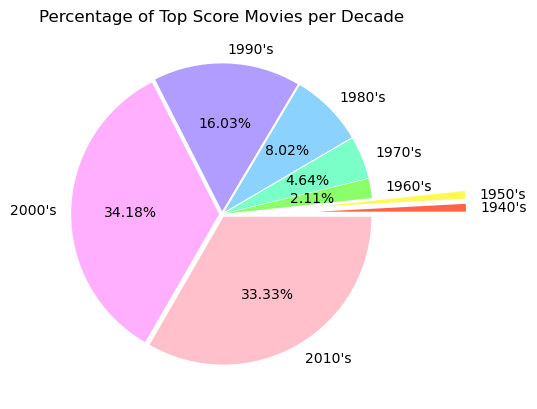

In [55]:
"""Data Visualization: Pie chart"""
key = decade_count.keys()
value = decade_count.values()
red = Color('tomato')
colors = list(red.range_to(Color('pink'), len(decade_count)))
# convert color range into RGB
colors = [c.rgb for c in colors]
# set explode
explode = [0.65 if x < 4 else 0.02 for x in value]
plt.pie(x = value, labels = key, colors = colors, explode = explode,
       autopct = lambda x: "{:1.2f}%".format(x) if x >= 2 else '')
plt.title('Percentage of Top Score Movies per Decade')

plt.show()

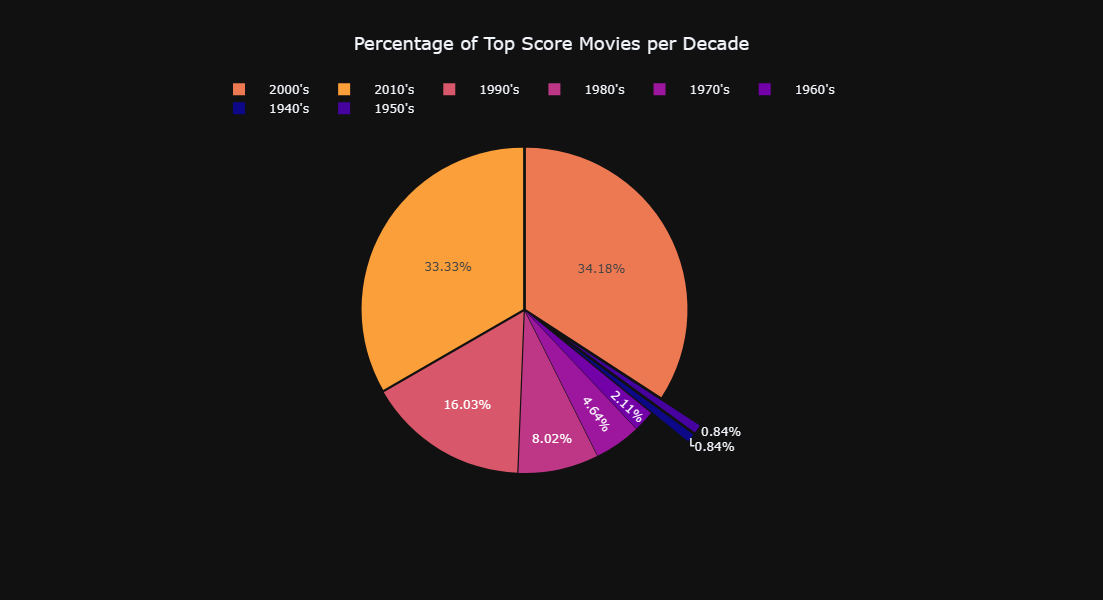

In [56]:
"""
Update: 4/27/2026
Generate interactive visualization using plotly
"""
decades = list(decade_count.keys())
counts = list(decade_count.values())
total = sum(counts)
percentages = [count/total*100 for count in counts]
# Calculate explode pct
pull = []
for pct in percentages:
    if pct <= 2:
        pull.append(0.3)
    else:
        pull.append(0.01)


fig = go.Figure(
    data = [go.Pie(
        labels = decades,
        values = percentages,
        text = percentages,
        texttemplate = '%{text:.2f}%',
        hovertemplate = '<b>%{label}</b><br>Count: %{customdata}<br>Percentage: %{value:.2f}%<extra></extra>',
        customdata = counts,
        marker = dict(colors = px.colors.sequential.Plasma),
        pull = pull
    )]
)
fig.update_layout(
    width = 800,
    height = 600,
    template = "plotly_dark",
    title_x = 0.5,
    title = {'text':'Percentage of Top Score Movies per Decade', 'font':{'size': 18}},
    legend = dict(orientation = 'h', xanchor = 'center', x = 0.5, y = 1.06, itemwidth = 50)
)
fig.show()

### Findings: 
1. 2000's decade has the most top score movies
2. Recent movies are more welcomed than old movies because:
   - Recent movies are closer to the aesthetics and life styles of modern audiences
   - Modern film technology is more advanced
   - Advanced cinemas in modern society offer better facilities and environments, which enhance the audience's viewing experience.

## Section 2. Content based filtering
### Functionality: 
- **Customized**: recommandation for users
- **Based on**: similarity between movies
- **Solution**: selected key features, generate metadata and calculate similarity scores between movies using text analytics.

#### Preparation 1: selected key features

In [57]:
movie_key = movie[['title', 'genres', 'keywords', 'cast', 'director']]
movie_key.head(5)

,title,genres,keywords,cast,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...",James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Sam Mendes
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...",Christopher Nolan
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...",Andrew Stanton


#### Preparation 2: Standardize feature shape(<=3)

In [58]:
"""
Date: 4/13/2026
Author: Shuang Liu
Function: get the top three element if count > 3 otherwise keep all
Parameters: df: name of dataframe
            feature: the given variable to get top 3 from
Output: df: updated dataframe
"""
def keep_three(df, feature):
    for i in range(len(df[feature])):
        if len(df[feature][i]) > 3:
            df[feature][i] = df[feature][i][:3]
        else:
            continue

    return df

for f in ['genres', 'keywords', 'cast']:
    movie_key = keep_three(movie_key, f)

movie_key.sample(3)

,title,genres,keywords,cast,director
903,Ted,"[Comedy, Fantasy]","[friendship, love, teddy bear]","[Mark Wahlberg, Mila Kunis, Seth MacFarlane]",Tim Hill
1704,The Big Short,"[Comedy, Drama]","[bank, fraud, biography]","[Christian Bale, Steve Carell, Ryan Gosling]",Jonathan Levine
4729,On The Downlow,[Drama],"[confession, hazing, gang member]","[Tony Sancho, Michael Cortez, Donato Cruz]",Jon Schroder


#### Preparation 3: Standardize spelling

In [59]:
"""
Date: 4/13/2026
Author: Shuang Liu
Function: remove all space and convert to lower case
Parameters: df: name of dataframe
            feature: given variable to clean
Output: df: updated dataframe
"""
def standardize_spelling(df, feature):
    for i in range(len(df[feature])):
        a = []
        for j in df[feature][i]:
            a.append((j.replace(' ', '')).lower())
        df[feature][i] = a     
    return df

for f in ['genres', 'keywords', 'cast']:
    movie_key = standardize_spelling(movie_key, f)

movie_key.sample(3)

,title,genres,keywords,cast,director
3963,Four Single Fathers,"[drama, comedy]",[],"[alessandrogassman, francescoquinn, joeurla]",Scott Foley
4636,Yesterday Was a Lie,"[drama, mystery, sciencefiction]",[independentfilm],"[chasemasterson, johnnewton, kipleighbrown]",Rob McKittrick
2036,Saving Silverman,"[comedy, crime, romance]","[femalenudity, harassment, malefriendship]","[jasonbiggs, stevezahn, jackblack]",Frank Darabont


In [60]:
# Standarize director
for i in range(len(movie_key['director'])):
    movie_key['director'][i] = (movie_key['director'][i].replace(' ', '')).lower()

movie_key.sample(3)

,title,genres,keywords,cast,director
1191,Small Soldiers,"[comedy, adventure, fantasy]","[defenseindustry, toyshop, technicaltoy]","[gregorysmith, kirstendunst, denisleary]",peterhowitt
2817,Witness,"[crime, drama, romance]","[corruption, detective, policebrutality]","[harrisonford, kellymcgillis, josefsommer]",peterkassovitz
4674,Echo Dr.,"[thriller, action, drama]",[],"[johnathanhurley, jordansavage, danebowman]",jonerwin


#### Preparation 4 generate metadata
- Combine all information into one string to summarize a movie

In [61]:
"""
Date: 4/13/2026
Author: Shuang Liu
Function: generate metadata for each movie
Parameters: x: each row in the data
Output: meta: a string with all information of the movie
"""
def meta(x):
    genres = ' '.join(x['genres'])
    keywords = ' '.join(x['keywords'])
    cast = ' '.join(x['cast'])
    director = x['director']
    # combined all
    meta = f'{genres} {keywords} {cast} {director}'
    return meta

movie_key['metadata'] = movie_key.apply(meta, axis = 1)
movie_key.head(3)

,title,genres,keywords,cast,director,metadata
0,Avatar,"[action, adventure, fantasy]","[cultureclash, future, spacewar]","[samworthington, zoesaldana, sigourneyweaver]",jamescameron,action adventure fantasy cultureclash future s...
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland]","[johnnydepp, orlandobloom, keiraknightley]",goreverbinski,adventure fantasy action ocean drugabuse exoti...
2,Spectre,"[action, adventure, crime]","[spy, basedonnovel, secretagent]","[danielcraig, christophwaltz, léaseydoux]",sammendes,action adventure crime spy basedonnovel secret...


### Performe vectorization using TF-IDF
- Term Frequency - Inverse Document Frequency
    - Concept: words occur more frequently in one document and less frequently in other documents will be given more importance.
- Given word(w) and a document(D)
- Term Frequency
  $$TF_w = \frac{Number\space of\space w\space in\space D}{Total\space w\space in\space D} $$
- Inverse Document Frequency
  $$IDF_w = log(\frac{Total\space D\space in\space Data}{Number\space of\space D\space with\space w}) $$
- TF-IDF
  $$TFIDF_w = TF_w \times IDF_w$$

#### Explanation: 
- D1 = it is nice outside
- D2 = the weather is nice
- D3 = I am outside
- Ws = [it, is, nice, outside, the, weather, I, am]
- Feature **vectors**
    - D1 = [1, 1, 1, 1, 0, 0, 0, 0]
    - D2 = [0, 1, 1, 0, 1, 1, 0, 0]
    - D3 = [0, 0, 0, 1, 0, 0, 1, 1]
- Calculate TFIDF:
    - TF nice = 1/4
    - IDF nice = log(3/2)
    - TFIDF = 1/4 * log(3/2)

In [62]:
# define a TfidfVectorizer, remove English stop words
tfidf = TfidfVectorizer(stop_words = 'english')
# construct a tfidf matrix by fitting to our movie data
tfidf_matrix = tfidf.fit_transform(movie_key['metadata'])
# check matrix shape
tfidf_matrix.shape

(4737, 11415)

### Calculate cosine similarity between movies
- Cosine similarity can be calculated using Euclidean dot product and norms
$$S_c(A,B) = cos(\theta) = \frac{A \cdot B}{\lVert A \rVert \lVert B \rVert} $$

In [63]:
"""
Example: Calculate cosine similarity between 1D matrices
"""
A = [1, 2, 3]
B = [3, 2, 1]

# Calculate dot product
dot_product = 0
for a,b in zip(A, B):
    dot_product += a*b

# Calculate norm A
norm_a = 0
for a in A:
    norm_a += a**2
norm_a = norm_a**0.5

# Calculate norm B
norm_b = 0
for b in B:
    norm_b += b**2
norm_b = norm_b**0.5

# Calculate cosine similarity
cs = dot_product / (norm_a * norm_b)
cs

0.7142857142857143

In [64]:
"""
Calculate Cosine similarity between 2D matrices
"""
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

B = np.array([
    [6, 5, 4],
    [3, 2, 1]
])

# Calculate norm for each line in A and B
# norm_a shape: 2 rows and 1 column

norm_a = np.linalg.norm(A, axis=1, keepdims=True)
norm_b = np.linalg.norm(B, axis=1, keepdims=True)

# Calculate dot product
# Dot product shape: 2 rows and 2 columns
"""
A shape: (m, n), B shape: (k, n)
cos(A, B) shape: (m, k)
"""

dot_product = A @ B.T
# Calculate cosine similarity
cos_sim = dot_product / (norm_a * norm_b.T)
cos_sim

array([[0.85280287, 0.71428571],
       [0.94805195, 0.85280287]])

In [65]:
cos_sim2 = cosine_similarity(A, B)
print(cos_sim2)

[[0.85280287 0.71428571]
 [0.94805195 0.85280287]]


In [66]:
# Applied method to our TFIDF metrics
cos_similarty_tfidf = cosine_similarity(tfidf_matrix, tfidf_matrix)
cos_similarty_tfidf
# Constract a maping of index and movie title
indices = pd.Series(movie_key.index, index = movie_key['title']).drop_duplicates()
indices

title
Avatar                                         0
Pirates of the Caribbean: At World's End       1
Spectre                                        2
The Dark Knight Rises                          3
John Carter                                    4
                                            ... 
Primer                                      4732
El Mariachi                                 4733
Newlyweds                                   4734
Signed, Sealed, Delivered                   4735
My Date with Drew                           4736
Length: 4737, dtype: int64

In [67]:
a = indices['The Avengers']
b = cos_similarty_tfidf[a]
c = list(enumerate(b))
d = sorted(c, key = lambda x: x[1], reverse = True)
e = []
for i in d[1:6]:
    e.append(i[0])
for j in e:
    print(indices.index[j])
    

Captain America: Civil War
Avengers: Age of Ultron
Captain America: The Winter Soldier
Iron Man 2
Captain America: The First Avenger


In [68]:
"""
Date: 5/18/2026
Author: Shuang Liu
Function: recommand top5 similar movies based on the given movie title.
Parameters: 
    title: title of the users' favorite movie
"""
def get_recommandations(title):
    # get index of favorite movie
    idx = indices[title] 
    # get the similarity score of all movies with the given movie
    sim_score = list(enumerate(cos_similarty_tfidf[idx])) 
    # get the top 5 movies that most similar with the given movie
    sim_top5 = sorted(sim_score, key = lambda x: x[1], reverse = True)[1:6] 
    # get the movie indices
    movie_indices = [i[0] for i in sim_top5]
    # return movies' name by index location
    print(f'The Top 5 Similar Movies to {title} are:')
    for i in [indices.index[j] for j in movie_indices]:
        print(f'\t{i}')

get_recommandations("The Avengers")

The Top 5 Similar Movies to The Avengers are:
	Captain America: Civil War
	Avengers: Age of Ultron
	Captain America: The Winter Soldier
	Iron Man 2
	Captain America: The First Avenger


# Summary
## Data Collection:
- **Merged multi-source datasets** of movie data, including information such as title, genres, keywords, votes, etc. As well as stuff and cast data.  
## Data Cleaning:
- Standardized datatype  
- Cleaned missing values  
- Performed **feature selection** and dropped uninformative variables, and filtered movies based on status.  
- Performed **feature engineering** based on existing variables, such as extracting director name from crew information, and star names from the cast.  
## Recommandation Systems:
### Demographic Filtering:
- Generated generalized recommandations based on **self-defined weighted rating metric** for every movie.  
- Designed **data visuallizations using matplotlib and Plotly(interactive)**.  
    - Explored the popular genres of top rated movies, using an interactive **bar chart**.  
    - Plotted a **word cloud** to understand which keywords were more welcomed among the audience.  
    - Created an interactive **pie chart** to show which decade of movies were more popular.  
### Content Based Filtering:
- Selected key features, standardize feature shape and spelling, and generated metadata for each movie.  
- Performed **vectorization using TF-IDF** techniques to convert the metadata text into numerical matrix.  
- **Calculated Euclidean cosine similarity scores** between movies by appling **linear algebra** concepts, and get top 5 movies with highest similarity scores.
- **Evaluation**: The recommanded movies based on our input movie title are mostly in line with our expectations. For example: as we input The Avengers, our recommandation states on returned three movies in the "Captain America" series, and another one Avenger series movie, and an "Iron man" series movie, which was quite reasonable.
## Extra Takeaways: Reusable Functions
- Defined a reusable function to deal with string of list of dictionaries, and grab specific values in the dictionaries.  
- Defined a reusable function to calculate generalize scores for any given movie dataset based on the IMDb rating formula.  
- Defined a reusable function to standardize spelling by removing spaces and unifying to lowercase.
- Defined a series of functions to **automatically manipulate movie data** through out the project to improve efficiency.